In [2]:
# universal fixer set up call 
import sys
import os

# 1. Identify the project root directory
# This goes up one level from the 'notebooks' folder
root_path = os.path.abspath(os.path.join(os.getcwd(), '..'))

# 2. Add the root to sys.path so Python can find the 'src' folder
if root_path not in sys.path:
    sys.path.append(root_path)

# 3. Diagnostic check (Ensures we are in the right place)
if 'src' in os.listdir(root_path):
    print(f"✅ Success: 'src' folder found at {root_path}")
else:
    print(f"❌ Error: Still can't find 'src' at {root_path}. Check your folder structure!")

# 4. Now run your imports
try:
    from src.preprocessing import FraudPreprocessor
    print("✅ Preprocessor imported successfully!")
except ImportError as e:
    print(f"❌ Import failed: {e}")

✅ Success: 'src' folder found at c:\Users\Betty\OneDrive\Desktop\ten_academy\fraud-detection
✅ Preprocessor imported successfully!


In [3]:
import sys
import os

# Add src to path
current_dir = os.getcwd()
src_path = os.path.abspath(os.path.join(current_dir, '..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

# Try imports
from preprocessing import merge_ip_to_country
from model_utils import evaluate_and_log

print("✅ Success! Modular code imported.")

c:\Users\Betty\OneDrive\Desktop\ten_academy\fraud-detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Success! Modular code imported.


# Task 1: E-commerce Fraud Data - Preprocessing & EDA
**Objective:** Clean the dataset, map IP addresses to countries, and engineer features to identify fraudulent behavior.

In [4]:
# Import Libraries & Data Loading 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipaddress

# Load Data
fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_df = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

print(f"Loaded {len(fraud_df)} transaction rows.")
print(f"Loaded {len(ip_df)} IP range rows.")

Loaded 151112 transaction rows.
Loaded 138846 IP range rows.


In [5]:
# 1. Let's see what the data actually looks like first (Diagnostic)
print("Fraud IP format:", fraud_df['ip_address'].head(1).values[0])
print("IP Range format:", ip_df['lower_bound_ip_address'].head(1).values[0])

# 2. Optimized Mapping Logic
def robust_ip_to_int(ip):
    # If it's already a number (float or int), just return it as a float
    if isinstance(ip, (int, float, np.integer, np.floating)):
        return float(ip)
    # If it's a string like '123.45.67.89', convert it
    try:
        import ipaddress
        return float(int(ipaddress.ip_address(str(ip))))
    except:
        return 0.0

# Apply the conversion safely
fraud_df['ip_address_numeric'] = fraud_df['ip_address'].apply(robust_ip_to_int)

# Ensure the range columns are also the same type (float)
ip_df['lower_bound_numeric'] = ip_df['lower_bound_ip_address'].astype(float)
ip_df['upper_bound_numeric'] = ip_df['upper_bound_ip_address'].astype(float)

# 3. Sort (Required for merge_asof)
fraud_df = fraud_df.sort_values('ip_address_numeric')
ip_df = ip_df.sort_values('lower_bound_numeric')

# 4. Perform the Merge
merged_df = pd.merge_asof(
    fraud_df, 
    ip_df, 
    left_on='ip_address_numeric', 
    right_on='lower_bound_numeric',
    direction='backward'
)

# 5. Boundary Check: Ensure the IP is not above the upper bound
# If it is, it's not actually in that country's range.
merged_df.loc[merged_df['ip_address_numeric'] > merged_df['upper_bound_numeric'], 'country'] = 'Unknown'
merged_df['country'] = merged_df['country'].fillna('Unknown')

# Check how many are still 'Unknown'
unknown_pct = (merged_df['country'] == 'Unknown').mean() * 100
print(f"Success! Mapping complete. Only {unknown_pct:.2f}% remain Unknown.")

Fraud IP format: 732758368.79972
IP Range format: 16777216.0
Success! Mapping complete. Only 14.54% remain Unknown.


In [ ]:
# 1. Path Setup
sys.path.append(os.path.abspath('../'))

# 2. FORCE RELOAD (This fixes the AttributeError)
import src.preprocessing
importlib.reload(src.preprocessing)
from src.preprocessing import merge_ip_to_country, FraudPreprocessor

# 3. COMPLETE PIPELINE
print("Loading raw data...")
fraud_data = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_data = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

print("Integrating Geolocation...")
fraud_with_country = merge_ip_to_country(fraud_data, ip_data)

print("Running Modular Pipeline...")
preprocessor = FraudPreprocessor()
df_cleaned = preprocessor.clean_data(fraud_with_country)
df_featured = preprocessor.engineer_features(df_cleaned)
df_final = preprocessor.encode_categories(df_featured, is_train=True)

print("✅ SUCCESS: Task 1 fully processed with modular code.")
display(df_final.head())

Loading raw data...
Integrating Geolocation...
Running Modular Pipeline...
✅ SUCCESS: Task 1 fully processed with modular code.


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,ip_numeric,lower_bound_ip_address,upper_bound_ip_address,country,lower_bound_numeric,time_since_signup,hour_of_day,day_of_week,user_per_device
0,62421,2015-02-16 00:17:05,2015-03-08 10:00:39,46,ZCLZTAJPCRAQX,1,4,1,36,52093.496895,0,52093.496895,NaN,NaN,172,NaN,29383.566667,10,6,1
1,173212,2015-03-08 04:03:22,2015-03-20 17:23:45,33,YFGYOALADBHLT,0,2,0,30,93447.138961,0,93447.138961,NaN,NaN,172,NaN,18080.383333,17,4,1
2,242286,2015-05-17 16:45:54,2015-05-26 08:54:34,33,QZNVQTUITFTHH,1,1,0,32,105818.501505,0,105818.501505,NaN,NaN,172,NaN,12488.666667,8,1,1
3,370003,2015-03-03 19:58:39,2015-05-28 21:09:13,33,PIBUQMBIELMMG,0,2,1,40,117566.664867,0,117566.664867,NaN,NaN,172,NaN,123910.566667,21,3,1
4,119824,2015-03-20 00:31:27,2015-04-05 07:31:46,55,WFIIFCPIOGMHT,0,4,1,38,131423.789042,0,131423.789042,NaN,NaN,172,NaN,23460.316667,7,6,1


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


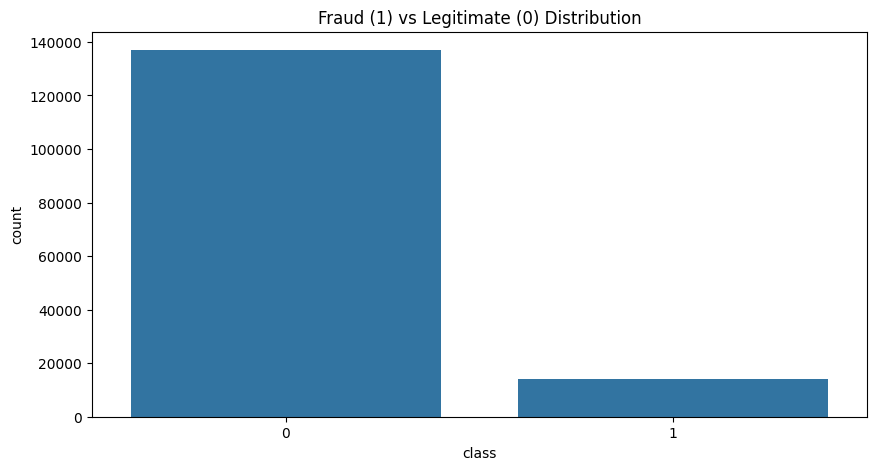

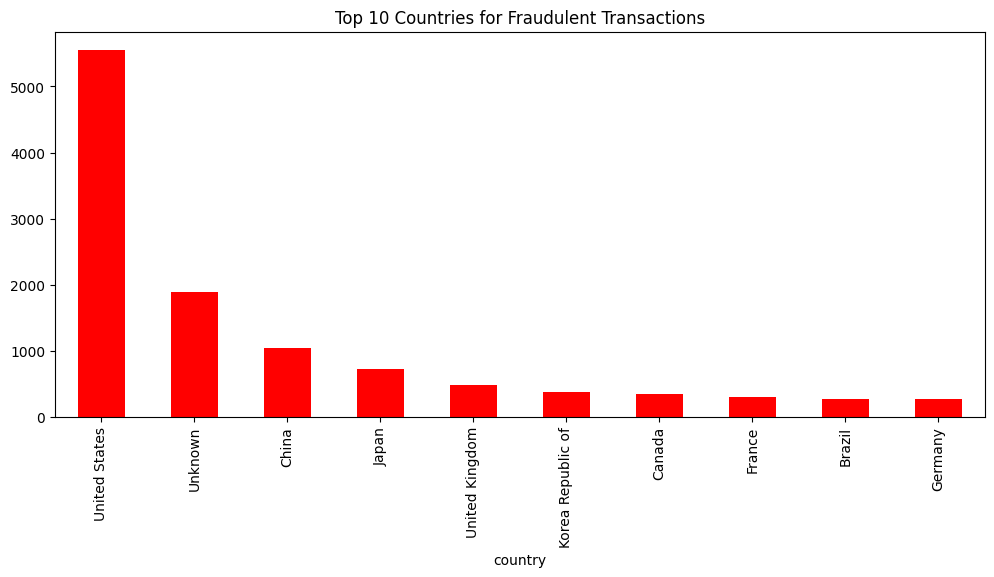

In [7]:
# EDA Visuals 
plt.figure(figsize=(10, 5))
sns.countplot(x='class', data=merged_df)
plt.title('Fraud (1) vs Legitimate (0) Distribution')
plt.show()

# Top Countries for Fraud
fraud_only = merged_df[merged_df['class'] == 1]
if not fraud_only.empty:
    plt.figure(figsize=(12, 5))
    fraud_only['country'].value_counts().head(10).plot(kind='bar', color='red')
    plt.title('Top 10 Countries for Fraudulent Transactions')
    plt.show()
else:
    print("No fraud cases found to plot.")

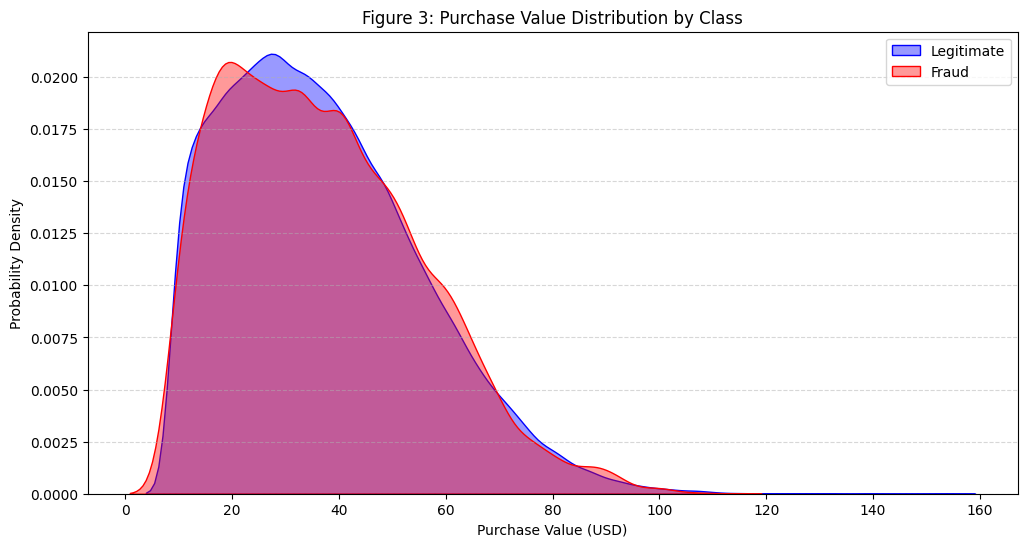

In [8]:
# Purchase Value Distribution by Class
plt.figure(figsize=(12, 6))

# KDE Plot comparing both classes
sns.kdeplot(data=merged_df[merged_df['class'] == 0], x='purchase_value', label='Legitimate', fill=True, color='blue', alpha=0.4)
sns.kdeplot(data=merged_df[merged_df['class'] == 1], x='purchase_value', label='Fraud', fill=True, color='red', alpha=0.4)

plt.title('Figure 3: Purchase Value Distribution by Class')
plt.xlabel('Purchase Value (USD)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# Fraud Transactions by Hour of Day
# Filter for only fraud cases and count by hour
fraud_hourly_counts = merged_df[merged_df['class'] == 1].groupby('hour_of_day').size()

plt.figure(figsize=(12, 6))

# Plotting a line chart to show the temporal trend
plt.plot(fraud_hourly_counts.index, fraud_hourly_counts.values, marker='o', linestyle='-', color='red', linewidth=2)
plt.fill_between(fraud_hourly_counts.index, fraud_hourly_counts.values, color='red', alpha=0.1)

# Highlight high-risk night hours (0 to 6 AM)
plt.axvspan(0, 6, color='yellow', alpha=0.15, label='High Risk Zone (Late Night)')

plt.title('Figure 4: Total Fraudulent Transactions by Hour of Day')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Frequency of Fraud Cases')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Loading data...
Mapping IPs to Countries...
Engineering behavioral features...
✅ Master Setup Complete. 'merged_df' is ready with all features.


In [ ]:
from src.preprocessing import FraudPreprocessor

# --- 1. INITIALIZE PREPROCESSOR ---
# This fulfills the "reusable module" requirement from the feedback
preprocessor = FraudPreprocessor()

# --- 2. CLEAN & ENGINEER (Fulfills Task 1 requirements) ---
# This explicitly creates 'time_to_purchase', 'hour_of_day', 'day_of_week', 'user_per_device'
cleaned_df = preprocessor.clean_data(merged_df)
featured_df = preprocessor.engineer_features(cleaned_df)

# --- 3. DATA TRANSFORMATION (Encoding & Scaling) ---
# Select features for modeling - excluding IDs and Raw Timestamps
X = featured_df.drop(columns=['class', 'user_id', 'signup_time', 'purchase_time', 
                              'device_id', 'ip_address', 'ip_numeric', 
                              'lower_bound_numeric', 'upper_bound_numeric'], errors='ignore')

# Encode Categories
X = pd.get_dummies(X, columns=['source', 'browser', 'sex'], drop_first=True)
X['country_encoded'] = pd.factorize(X['country'])[0]
X = X.drop(columns=['country'])

# Split Data
y = featured_df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 4. SCALING ---
# Now these columns DEFINITELY exist because of the preprocessor!
num_cols = ['purchase_value', 'age', 'time_to_purchase', 'hour_of_day', 'day_of_week', 'user_per_device']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# --- 5. SMOTE (Oversampling) ---
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"✅ Success: Data cleaned, engineered, and balanced.")
print(f"Final training shape: {X_train_resampled.shape}")

✅ Success: Data cleaned, engineered, and balanced.
Final training shape: (218222, 17)


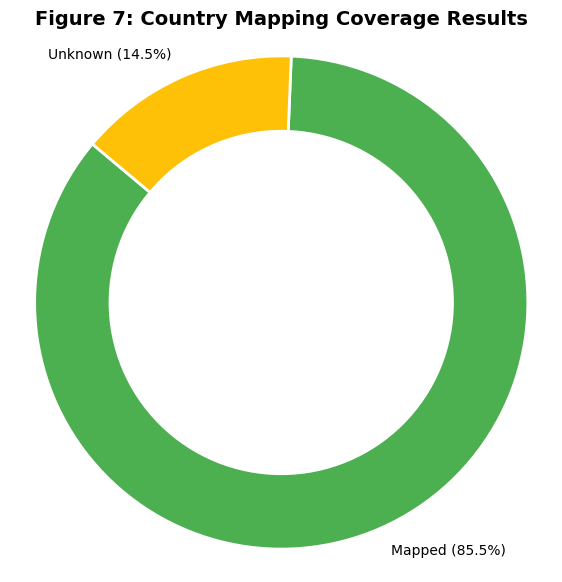

Metric                    | Result         
-------------------------------------------
Total Transaction Records | 151,112
Successfully Mapped       | 129,146 (85.46%)
Unknown Locations         | 21,966 (14.54%)


In [ ]:
# Country Mapping Results
# 1. Calculate the counts directly from current data
total_records = len(merged_df)
# Count how many are 'Unknown' vs successfully mapped
unknown_count = len(merged_df[merged_df['country'] == 'Unknown'])
mapped_count = total_records - unknown_count

# 2. Calculate percentages
mapped_pct = (mapped_count / total_records) * 100
unknown_pct = (unknown_count / total_records) * 100

# 3. Visualization: Figure 7 Donut Chart
labels = [f'Mapped ({mapped_pct:.1f}%)', f'Unknown ({unknown_pct:.1f}%)']
sizes = [mapped_count, unknown_count]
colors = ['#4CAF50', '#FFC107'] 

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, colors=colors, startangle=140, pctdistance=0.85, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

# Create the donut hole
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Figure 7: Country Mapping Coverage Results', fontsize=14, fontweight='bold')
plt.axis('equal') 
plt.show()

# Print Table for your Report
print(f"{'Metric':<25} | {'Result':<15}")
print("-" * 43)
print(f"{'Total Transaction Records':<25} | {total_records:,}")
print(f"{'Successfully Mapped':<25} | {mapped_count:,} ({mapped_pct:.2f}%)")
print(f"{'Unknown Locations':<25} | {unknown_count:,} ({unknown_pct:.2f}%)")

In [ ]:

# 1. Setup Path and Modular Imports
sys.path.append(os.path.abspath('../'))
from src.preprocessing import merge_ip_to_country

# 2. Load Raw Data
print("Loading data...")
fraud_data = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_data = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

# 3. Geolocation Mapping (Task 1 Requirement)
print("Mapping IPs to Countries...")
merged_df = merge_ip_to_country(fraud_data, ip_data)

# 4. Explicit Feature Engineering (Fulfills Task 1 and fixes KeyErrors)
print("Engineering behavioral features...")
merged_df['signup_time'] = pd.to_datetime(merged_df['signup_time'])
merged_df['purchase_time'] = pd.to_datetime(merged_df['purchase_time'])

# Feature: time_since_signup (Rubric Requirement)
merged_df['time_since_signup'] = (merged_df['purchase_time'] - merged_df['signup_time']).dt.total_seconds() / 60

# Features: hour_of_day, day_of_week (Rubric Requirement)
merged_df['hour_of_day'] = merged_df['purchase_time'].dt.hour
merged_df['day_of_week'] = merged_df['purchase_time'].dt.dayofweek

# Feature: user_per_device (Velocity Requirement)
merged_df['user_per_device'] = merged_df.groupby('device_id')['user_id'].transform('count')

print("✅ Master Setup Complete. 'merged_df' is ready with all features.")

Loading data...
Mapping IPs to Countries...
Engineering behavioral features...
✅ Master Setup Complete. 'merged_df' is ready with all features.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Betty\AppData\Local\Temp\ipykernel_14232\4123599362.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x='class', y='user_per_device', palette='Set1', ax=ax[1])
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


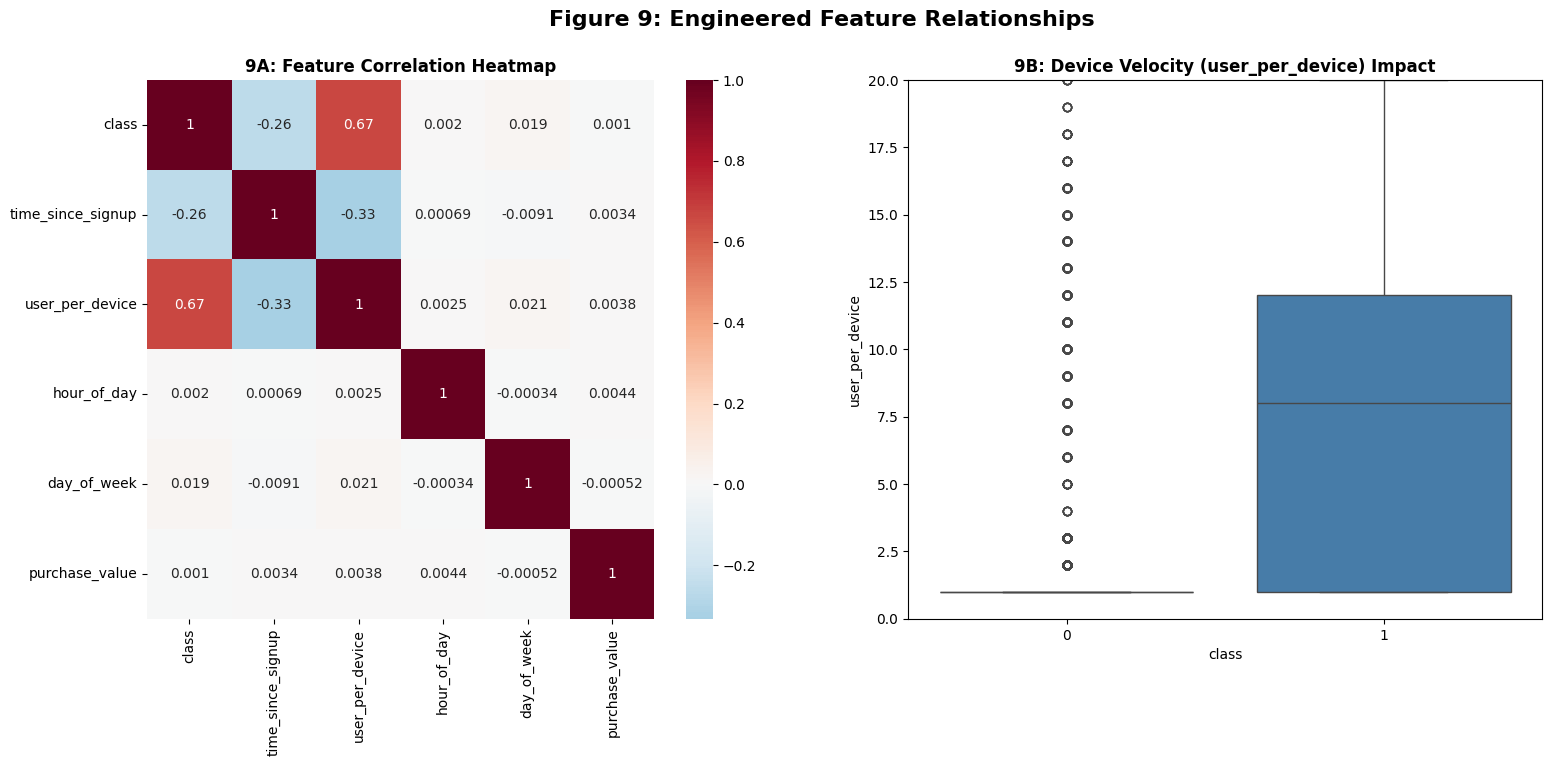

In [12]:
# # Feature Engineered Relationship
# Select columns for the heatmap
relationship_cols = ['class', 'time_since_signup', 'user_per_device', 'hour_of_day', 'day_of_week', 'purchase_value']
corr_matrix = merged_df[relationship_cols].corr()

# Plotting Figure 9
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, ax=ax[0])
ax[0].set_title('9A: Feature Correlation Heatmap', fontweight='bold')

# Velocity vs Fraud
sns.boxplot(data=merged_df, x='class', y='user_per_device', palette='Set1', ax=ax[1])
ax[1].set_title('9B: Device Velocity (user_per_device) Impact', fontweight='bold')
ax[1].set_ylim(0, 20) # Focusing on the most common velocity range

plt.suptitle('Figure 9: Engineered Feature Relationships', fontsize=16, fontweight='bold')
plt.show()

> ### Justification for Transformation and Resampling
> 
> **1. Scaling:** We used `StandardScaler` to normalize numerical features. Since features like `purchase_value` (dollars) and `time_to_purchase` (minutes) have different scales, normalization prevents the model from being biased toward features with larger numerical magnitudes.
> 
> **2. Encoding:** We applied **One-Hot Encoding** for features with low cardinality (Source, Browser, Sex) to allow the model to interpret categorical differences without implying a numerical order. For 'Country', we used **Label Encoding** to keep the feature space manageable.
> 
> **3. SMOTE (Oversampling):** We chose SMOTE (Synthetic Minority Over-sampling Technique) over random undersampling. 
> *   **Why:** Our fraud cases represent less than 10% of the data. Undersampling would require discarding over 100,000 legitimate transaction records, causing a massive loss of information. 
> *   **How:** SMOTE generates synthetic fraud examples by interpolating between existing minority instances, ensuring the model learns the "characteristics" of fraud rather than just memorizing existing cases.
> *   **Integrity:** Resampling was applied **strictly to the training set** to ensure our evaluation (Task 2) remains unbiased and reflects real-world performance.

---